In [14]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

In [15]:
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

X = newsgroups.data
y = newsgroups.target

print("Number of documents:", len(X))
print("Number of classes:", len(newsgroups.target_names))
print("First category:", newsgroups.target_names[0])

Number of documents: 18846
Number of classes: 20
First category: alt.atheism


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training documents:", len(X_train))
print("Testing documents:", len(X_test))

Training documents: 15076
Testing documents: 3770


In [17]:
vectorizer = CountVectorizer(stop_words="english")

X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_counts.shape)
print("Testing matrix shape:", X_test_counts.shape)

Training matrix shape: (15076, 123239)
Testing matrix shape: (3770, 123239)


In [18]:
X_train_counts = X_train_counts.toarray()

word_totals = X_train_counts.sum(axis=0)
total_words = word_totals.sum()

print("Vocabulary Size:", len(word_totals))
print("Total Words:", total_words)

Vocabulary Size: 123239
Total Words: 1582978


In [19]:
mle_probs = word_totals / total_words

print("First 10 MLE probabilities:")
print(mle_probs[:10])

print("Sum of MLE probabilities:", mle_probs.sum())

First 10 MLE probabilities:
[1.11940911e-03 5.95712638e-04 5.68548647e-06 3.79032431e-06
 6.31720719e-07 1.26344144e-06 1.26344144e-06 1.26344144e-06
 1.26344144e-06 1.26344144e-06]
Sum of MLE probabilities: 1.0


In [20]:
alphas = [0.1, 1, 10]

map_probs = {}

for alpha in alphas:
    map_probs[alpha] = (word_totals + alpha) / (
        total_words + alpha * len(word_totals)
    )

In [21]:
comparison = pd.DataFrame({
    "MLE": mle_probs,
    "MAP_alpha_0.1": map_probs[0.1],
    "MAP_alpha_1": map_probs[1],
    "MAP_alpha_10": map_probs[10]
})

print(comparison.head(10))

            MLE  MAP_alpha_0.1  MAP_alpha_1  MAP_alpha_10
0  1.119409e-03   1.110824e-03     0.001039      0.000633
1  5.957126e-04   5.911734e-04     0.000553      0.000338
2  5.685486e-06   5.704249e-06     0.000006      0.000007
3  3.790324e-06   3.823728e-06     0.000004      0.000006
4  6.317207e-07   6.895247e-07     0.000001      0.000004
5  1.263441e-06   1.316365e-06     0.000002      0.000004
6  1.263441e-06   1.316365e-06     0.000002      0.000004
7  1.263441e-06   1.316365e-06     0.000002      0.000004
8  1.263441e-06   1.316365e-06     0.000002      0.000004
9  1.263441e-06   1.316365e-06     0.000002      0.000004


In [22]:
feature_names = vectorizer.get_feature_names_out()

comparison = pd.DataFrame({
    "Word": feature_names,
    "Count": word_totals,
    "MLE": mle_probs,
    "MAP_alpha_0.1": map_probs[0.1],
    "MAP_alpha_1": map_probs[1],
    "MAP_alpha_10": map_probs[10]
})

print(comparison.head(10))

         Word  Count           MLE  MAP_alpha_0.1  MAP_alpha_1  MAP_alpha_10
0          00   1772  1.119409e-03   1.110824e-03     0.001039      0.000633
1         000    943  5.957126e-04   5.911734e-04     0.000553      0.000338
2        0000      9  5.685486e-06   5.704249e-06     0.000006      0.000007
3       00000      6  3.790324e-06   3.823728e-06     0.000004      0.000006
4      000000      1  6.317207e-07   6.895247e-07     0.000001      0.000004
5    00000000      2  1.263441e-06   1.316365e-06     0.000002      0.000004
6  0000000004      2  1.263441e-06   1.316365e-06     0.000002      0.000004
7   00000000b      2  1.263441e-06   1.316365e-06     0.000002      0.000004
8    00000001      2  1.263441e-06   1.316365e-06     0.000002      0.000004
9   00000001b      2  1.263441e-06   1.316365e-06     0.000002      0.000004


In [23]:
rare_words = comparison.sort_values("Count").head(10)

print(rare_words)

                 Word  Count           MLE  MAP_alpha_0.1  MAP_alpha_1  \
54358          grrjku      1  6.317207e-07   6.895247e-07     0.000001   
54377         gruesse      1  6.317207e-07   6.895247e-07     0.000001   
54378       gruffness      1  6.317207e-07   6.895247e-07     0.000001   
54381  grumblegrumble      1  6.317207e-07   6.895247e-07     0.000001   
54382       grumbling      1  6.317207e-07   6.895247e-07     0.000001   
54383         grumman      1  6.317207e-07   6.895247e-07     0.000001   
54353         growths      1  6.317207e-07   6.895247e-07     0.000001   
54355        grpahics      1  6.317207e-07   6.895247e-07     0.000001   
54356          grpxjq      1  6.317207e-07   6.895247e-07     0.000001   
54357             grr      1  6.317207e-07   6.895247e-07     0.000001   

       MAP_alpha_10  
54358      0.000004  
54377      0.000004  
54378      0.000004  
54381      0.000004  
54382      0.000004  
54383      0.000004  
54353      0.000004  
54355    

In [24]:
print("Sum of MLE probabilities:", mle_probs.sum())

for alpha in alphas:
    print(
        f"Sum of MAP probabilities for alpha={alpha}:",
        map_probs[alpha].sum()
    )

Sum of MLE probabilities: 1.0
Sum of MAP probabilities for alpha=0.1: 1.0
Sum of MAP probabilities for alpha=1: 0.9999999999999999
Sum of MAP probabilities for alpha=10: 1.0


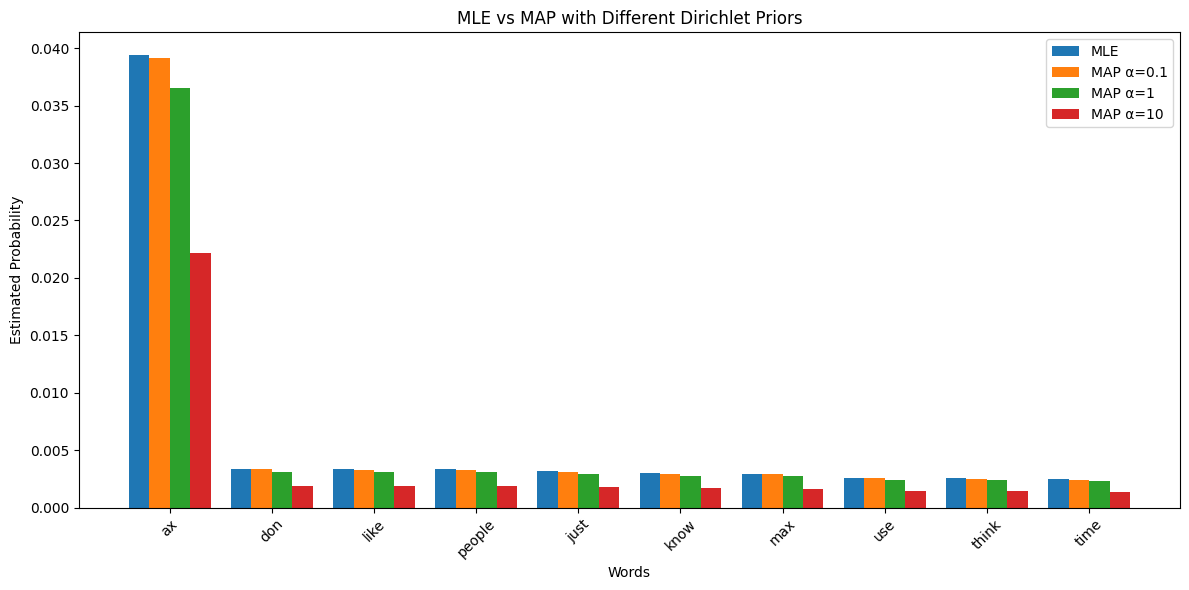

In [25]:
top_words = comparison.sort_values("Count", ascending=False).head(10)

x = np.arange(len(top_words))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5 * width, top_words["MLE"], width, label="MLE")
plt.bar(x - 0.5 * width, top_words["MAP_alpha_0.1"], width, label="MAP α=0.1")
plt.bar(x + 0.5 * width, top_words["MAP_alpha_1"], width, label="MAP α=1")
plt.bar(x + 1.5 * width, top_words["MAP_alpha_10"], width, label="MAP α=10")

plt.xticks(x, top_words["Word"], rotation=45)
plt.xlabel("Words")
plt.ylabel("Estimated Probability")
plt.title("MLE vs MAP with Different Dirichlet Priors")
plt.legend()
plt.tight_layout()
plt.show()